In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "aljarah/xAPI-Edu-Data",
  "xAPI-Edu-Data.csv",
)

In [2]:
df.shape

(480, 17)

In [3]:
df.head(10)

,gender,NationalITy,PlaceofBirth,StageID,GradeID,SectionID,Topic,Semester,Relation,raisedhands,VisITedResources,AnnouncementsView,Discussion,ParentAnsweringSurvey,ParentschoolSatisfaction,StudentAbsenceDays,Class
0,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,15,16,2,20,Yes,Good,Under-7,M
1,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,20,20,3,25,Yes,Good,Under-7,M
2,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,10,7,0,30,No,Bad,Above-7,L
3,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,30,25,5,35,No,Bad,Above-7,L
4,M,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,40,50,12,50,No,Bad,Above-7,M
5,F,KW,KuwaIT,lowerlevel,G-04,A,IT,F,Father,42,30,13,70,Yes,Bad,Above-7,M
6,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,35,12,0,17,No,Bad,Above-7,L
7,M,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,50,10,15,22,Yes,Good,Under-7,M
8,F,KW,KuwaIT,MiddleSchool,G-07,A,Math,F,Father,12,21,16,50,Yes,Good,Under-7,M
9,F,KW,KuwaIT,MiddleSchool,G-07,B,IT,F,Father,70,80,25,70,Yes,Good,Under-7,M


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 480 entries, 0 to 479
Data columns (total 17 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   gender                    480 non-null    object
 1   NationalITy               480 non-null    object
 2   PlaceofBirth              480 non-null    object
 3   StageID                   480 non-null    object
 4   GradeID                   480 non-null    object
 5   SectionID                 480 non-null    object
 6   Topic                     480 non-null    object
 7   Semester                  480 non-null    object
 8   Relation                  480 non-null    object
 9   raisedhands               480 non-null    int64 
 10  VisITedResources          480 non-null    int64 
 11  AnnouncementsView         480 non-null    int64 
 12  Discussion                480 non-null    int64 
 13  ParentAnsweringSurvey     480 non-null    object
 14  ParentschoolSatisfaction  

In [5]:
df.isnull().sum()

gender                      0
NationalITy                 0
PlaceofBirth                0
StageID                     0
GradeID                     0
SectionID                   0
Topic                       0
Semester                    0
Relation                    0
raisedhands                 0
VisITedResources            0
AnnouncementsView           0
Discussion                  0
ParentAnsweringSurvey       0
ParentschoolSatisfaction    0
StudentAbsenceDays          0
Class                       0
dtype: int64

In [6]:
df['Class'].value_counts()

Class
M    211
H    142
L    127
Name: count, dtype: int64

In [7]:
df['gender'].value_counts()

gender
M    305
F    175
Name: count, dtype: int64

In [8]:
df['StudentAbsenceDays'].value_counts()

StudentAbsenceDays
Under-7    289
Above-7    191
Name: count, dtype: int64

In [9]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols

['raisedhands', 'VisITedResources', 'AnnouncementsView', 'Discussion']

In [10]:
df[numeric_cols].corr()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
raisedhands,1.000000,0.691572,0.643918,0.339386
VisITedResources,0.691572,1.000000,0.594500,0.243292
AnnouncementsView,0.643918,0.594500,1.000000,0.417290
Discussion,0.339386,0.243292,0.417290,1.000000


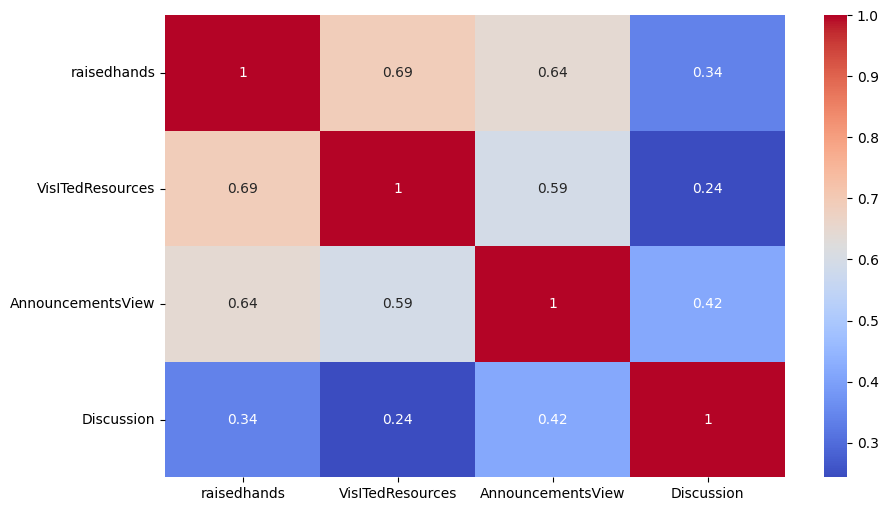

In [11]:
plt.figure(figsize=(10, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.show()

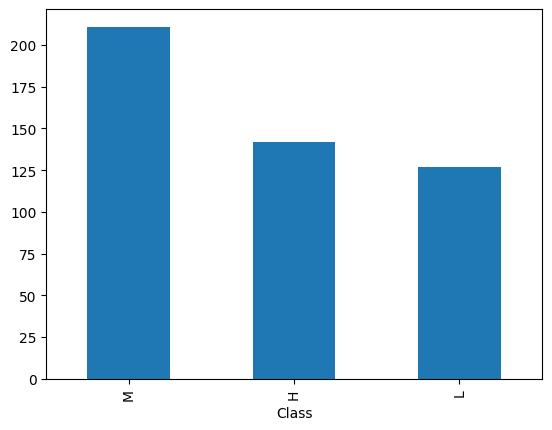

In [12]:
df['Class'].value_counts().plot(kind='bar')
plt.show()

In [13]:
df.groupby('Class')[numeric_cols].mean()

,raisedhands,VisITedResources,AnnouncementsView,Discussion
Class,,,,
H,70.288732,78.746479,53.380282,53.661972
L,16.889764,18.322835,15.574803,30.834646
M,48.938389,60.635071,40.962085,43.791469


In [14]:
pd.crosstab(df['StudentAbsenceDays'], df['Class'])

Class,H,L,M
StudentAbsenceDays,,,
Above-7,4,116,71
Under-7,138,11,140


<Figure size 800x400 with 0 Axes>

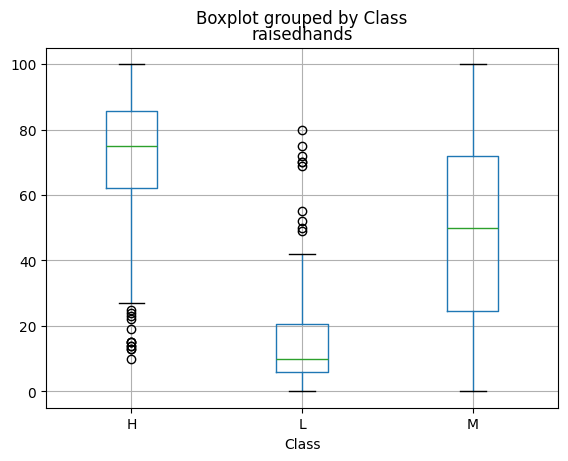

<Figure size 800x400 with 0 Axes>

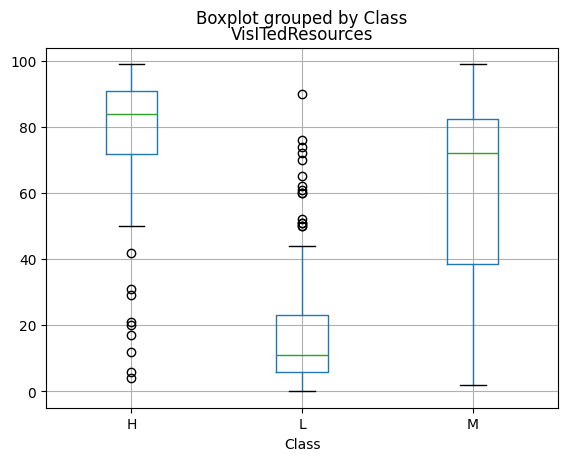

<Figure size 800x400 with 0 Axes>

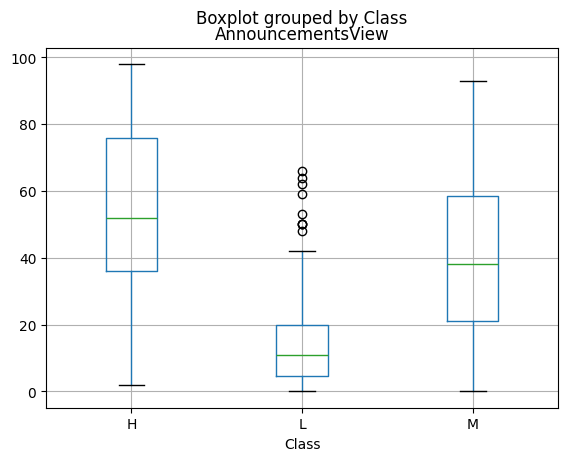

<Figure size 800x400 with 0 Axes>

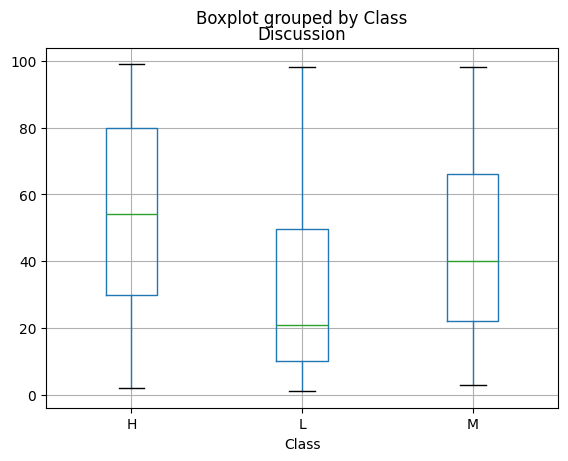

In [15]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    df.boxplot(column=col, by='Class')
    plt.show()

In [16]:
pd.crosstab(df['ParentAnsweringSurvey'], df['Class'], normalize='index')

Class,H,L,M
ParentAnsweringSurvey,,,
No,0.133333,0.471429,0.395238
Yes,0.422222,0.103704,0.474074


In [17]:
pd.crosstab(df['ParentschoolSatisfaction'], df['Class'], normalize='index')

Class,H,L,M
ParentschoolSatisfaction,,,
Bad,0.12766,0.446809,0.425532
Good,0.40411,0.147260,0.448630


In [18]:
df['engagement_score'] = df['raisedhands'] + df['VisITedResources'] + df['AnnouncementsView'] + df['Discussion']
df.groupby('Class')['engagement_score'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
H,142.0,256.077465,63.839790,74.0,219.5,258.0,307.0,368.0
L,127.0,81.622047,47.771767,4.0,49.5,75.0,115.5,254.0
M,211.0,194.327014,75.438478,18.0,143.0,190.0,253.5,358.0


<Figure size 1000x500 with 0 Axes>

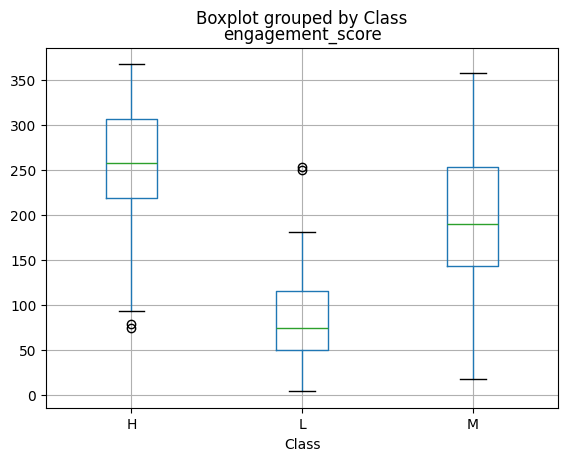

In [19]:
plt.figure(figsize=(10, 5))
df.boxplot(column='engagement_score', by='Class')
plt.show()

In [20]:
high_risk = df[df['Class'] == 'L']
print("Total at-risk students:", len(high_risk))
print("Average absences:", (high_risk['StudentAbsenceDays'] == 'Above-7').mean())
print("Average engagement:", high_risk['engagement_score'].mean())
print("Parent survey response:", (high_risk['ParentAnsweringSurvey'] == 'Yes').mean())

Total at-risk students: 127
Average absences: 0.9133858267716536
Average engagement: 81.62204724409449
Parent survey response: 0.2204724409448819


In [21]:
low_engagement = df[df['engagement_score'] < 50]
pd.crosstab(low_engagement['StudentAbsenceDays'], low_engagement['Class'])

Class,L,M
StudentAbsenceDays,,
Above-7,28,3
Under-7,4,1


In [22]:
df['at_risk'] = (df['Class'] == 'L').astype(int)
df['at_risk'].value_counts()

at_risk
0    353
1    127
Name: count, dtype: int64